Actividad 2, nivel 2

Estudiantes:
Natalia Macana, Samuel Melo y Mallory Meneses

Para este ejercicio se seleccionó un _dataset_ de Kaggle, el cual se consideró que era útil para reforzar conocimientos y realizar el presente ejercicio.

El archivo escogido es sobre acoso sexual en Nueva Zelanda, el cual tiene de origen la institución que lleva las estadísticas de ese país -dato encontrado en el transcurso del ejercicio-. Este set de datos tiene un tamaño de 2020 registros que corresponden a ciudades del país.

In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Cargar el documento
# Lectura
from google.colab import drive
drive.mount('/gdrive')

ruta = "/content/analysis-public-place-assaults-sexual-assaults-and-robberies-2015-csv (1).csv"
data = pd.read_csv(ruta)

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).


In [ ]:
# Leer y cargar el CSV
data = pd.read_csv("analysis-public-place-assaults-sexual-assaults-and-robberies-2015-csv (1).csv")

# Ver qué hay en el DataFrame
data.head()

,Index,Area_unit_2013_code,Area_unit_2013_label,Victimisations_calendar_year_2015,Population_mid_point_2015,Rate_per_10000_population,Rate_ratio_NZ_average_rate,Urban_area_2013_code,Urban_area_2013_label,Urban_area_type,Territorial_authority_area_2013_code,Territorial_authority_area_2013_label,Region_2013_code,Region_2013_label
0,1,514102,Auckland Central West,550,15900,346,6.6,4,Central Auckland Zone,Main urban area,76,Auckland,2,Auckland Region
1,2,573101,Willis Street-Cambridge Terrace,447,8300,539,10.3,20,Wellington Zone,Main urban area,47,Wellington City,9,Wellington Region
2,3,529700,Hamilton Central,380,3170,"1,199",22.9,6,Hamilton Zone,Main urban area,16,Hamilton City,3,Waikato Region
3,4,514103,Auckland Central East,375,13250,283,5.4,4,Central Auckland Zone,Main urban area,76,Auckland,2,Auckland Region
4,5,591500,Cathedral Square,305,570,"5,351",102.3,22,Christchurch,Main urban area,60,Christchurch City,13,Canterbury Region


In [ ]:
data.dtypes

,0
Index,int64
Area_unit_2013_code,int64
Area_unit_2013_label,object
Victimisations_calendar_year_2015,int64
Population_mid_point_2015,int64
Rate_per_10000_population,object
Rate_ratio_NZ_average_rate,object
Urban_area_2013_code,int64
Urban_area_2013_label,object
Urban_area_type,object


In [ ]:
print("Número original de datapoints\n", data.shape) # Filas x Columnas

# Elimina cualquier valor faltante y remplazarlos hacia la variable de los datos
data = data.dropna()

# Comprueba la nueva forma (shape)
print("Número actualizado de datapoints\n", data.shape) # Filas x Columnas

Número original de datapoints
 (2020, 14)
Número actualizado de datapoints
 (2020, 14)


# Limpieza de datos

In [ ]:
data.dropna(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 14 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Index                                  2020 non-null   int64 
 1   Area_unit_2013_code                    2020 non-null   int64 
 2   Area_unit_2013_label                   2020 non-null   object
 3   Victimisations_calendar_year_2015      2020 non-null   int64 
 4   Population_mid_point_2015              2020 non-null   int64 
 5    Rate_per_10000_population             2020 non-null   object
 6    Rate_ratio_NZ_average_rate            2020 non-null   object
 7   Urban_area_2013_code                   2020 non-null   int64 
 8   Urban_area_2013_label                  2020 non-null   object
 9   Urban_area_type                        2020 non-null   object
 10  Territorial_authority_area_2013_code   2020 non-null   int64 
 11  Territorial_autho

In [ ]:
data.columns = data.columns.str.strip()

Se eliminaron los espacios al inicio en el nombre de algunas variables.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 14 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Index                                  2020 non-null   int64 
 1   Area_unit_2013_code                    2020 non-null   int64 
 2   Area_unit_2013_label                   2020 non-null   object
 3   Victimisations_calendar_year_2015      2020 non-null   int64 
 4   Population_mid_point_2015              2020 non-null   int64 
 5   Rate_per_10000_population              2020 non-null   object
 6   Rate_ratio_NZ_average_rate             2020 non-null   object
 7   Urban_area_2013_code                   2020 non-null   int64 
 8   Urban_area_2013_label                  2020 non-null   object
 9   Urban_area_type                        2020 non-null   object
 10  Territorial_authority_area_2013_code   2020 non-null   int64 
 11  Territorial_autho

In [ ]:
# Conteo de los niveles en las diferentes columnas categóricas
cols_cat = ['Area_unit_2013_label', 'Rate_per_10000_population', 'Rate_ratio_NZ_average_rate', 'Urban_area_2013_label', 'Urban_area_type',
            'Territorial_authority_area_2013_label', 'Region_2013_label']

for col in cols_cat:
  # Check if the column exists in the DataFrame before accessing it
  if col in data.columns:
    print(f'Columna {col}: {data[col].nunique()} subniveles')
  else:
    print(f'Columna {col} no encontrada en el DataFrame.')

Columna Area_unit_2013_label: 2020 subniveles
Columna Rate_per_10000_population: 238 subniveles
Columna Rate_ratio_NZ_average_rate: 102 subniveles
Columna Urban_area_2013_label: 150 subniveles
Columna Urban_area_type: 4 subniveles
Columna Territorial_authority_area_2013_label: 68 subniveles
Columna Region_2013_label: 17 subniveles


In [ ]:
data.describe()

,Index,Area_unit_2013_code,Victimisations_calendar_year_2015,Population_mid_point_2015,Urban_area_2013_code,Territorial_authority_area_2013_code,Region_2013_code
count,2020.000000,2020.000000,2020.000000,2020.000000,2020.000000,2020.000000,2020.000000
mean,1010.500000,558310.185644,11.898515,2274.975248,190.513861,71.168317,8.205941
std,583.268092,36014.196850,27.959854,1871.846299,221.931445,143.492317,10.171251
min,1.000000,500100.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,505.750000,526176.500000,1.000000,660.000000,10.000000,31.000000,2.000000
50%,1010.500000,555350.000000,4.000000,1985.000000,23.000000,53.000000,7.000000
75%,1515.250000,587302.250000,13.000000,3462.500000,502.000000,75.000000,13.000000
max,2020.000000,666673.000000,550.000000,15900.000000,511.000000,999.000000,99.000000


Las 7 columnas numéricas tienen desviaciones estándar diferentes a 0, por lo tanto, mantendremos dichas columnas.

# Filas repetidas

In [ ]:
print(f'Tamaño del set antes de eliminar las filas repetidas: {data.shape}')
data.drop_duplicates(inplace=True)
print(f'Tamaño del set después de eliminar las filas repetidas: {data.shape}')

Tamaño del set antes de eliminar las filas repetidas: (2020, 14)
Tamaño del set después de eliminar las filas repetidas: (2020, 14)


Dada la naturaleza del dataset, que son datos registrados por ciudad en el año estudiado, no hay filas repetidas en el set de datos.

# _Outliers_ de variables numéricas

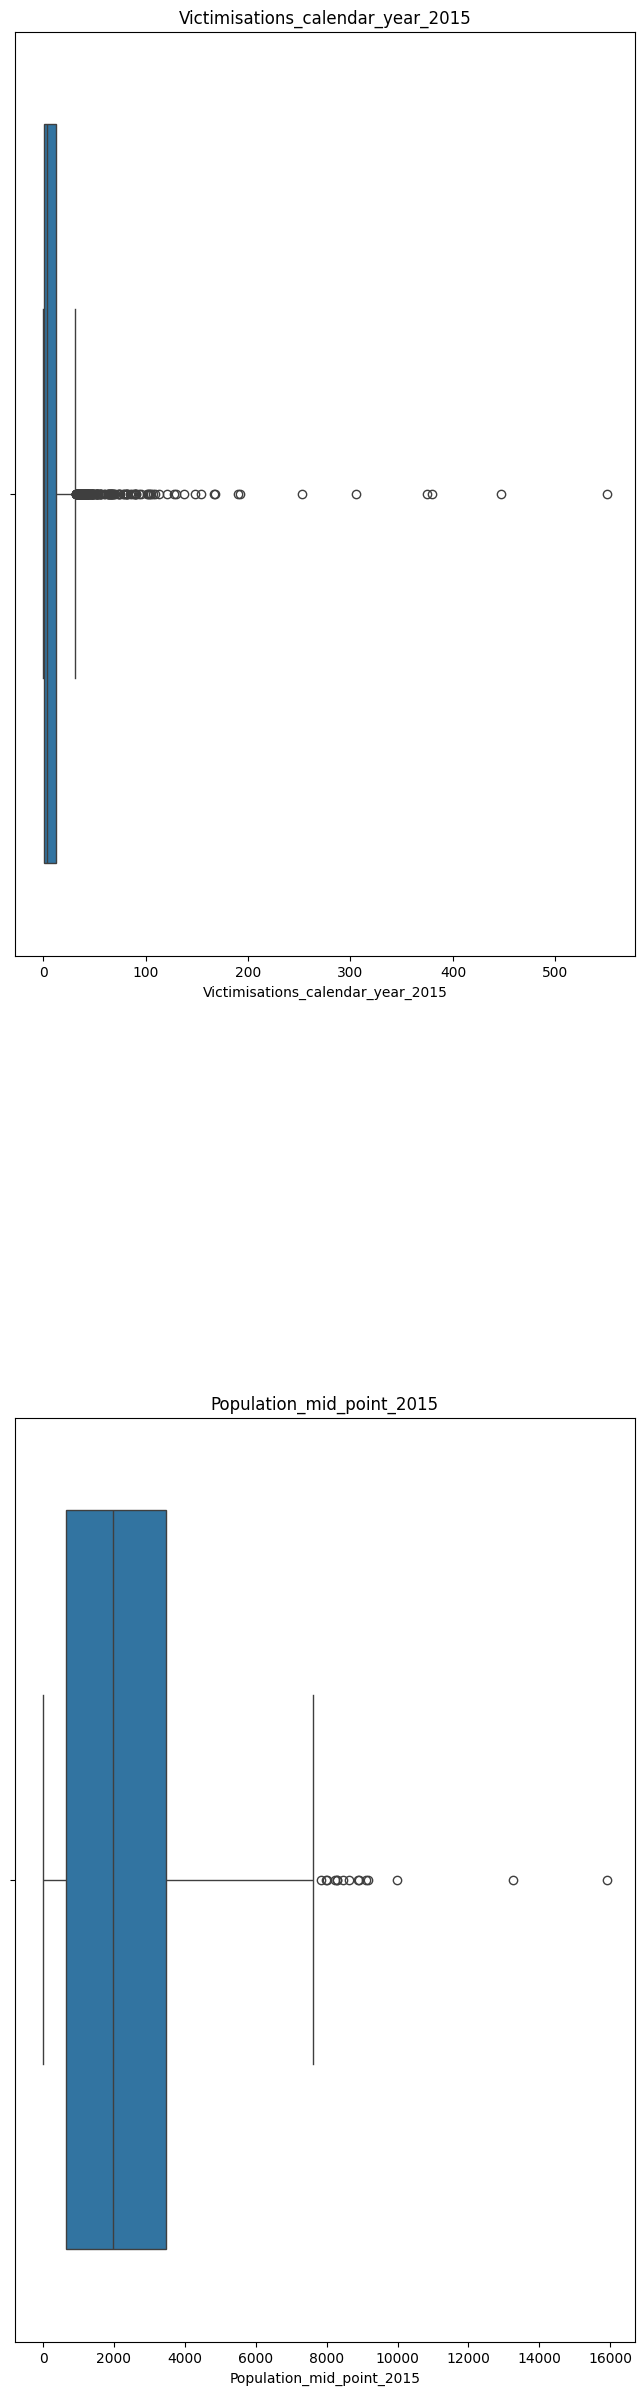

In [ ]:
cols_num = ['Victimisations_calendar_year_2015', 'Population_mid_point_2015']

fig, ax = plt.subplots(nrows=len(cols_num), ncols=1, figsize=(8,30))
fig.subplots_adjust(hspace=0.5)

for i, col in enumerate(cols_num):
    sns.boxplot(x=col, data=data, ax=ax[i])
    ax[i].set_title(col)

Observaciones de las variables:

"victimisations_calendar_2015": hay valores muy altos, lo que indica que son atípicos.
"Population_mid_point_2015": hay muchos atípicos, por valores altos.

Lo anterior puede explicarse dada la distribución demográfica que presentan las grandes ciudades comparadas con lugares menos densos poblacionalmente. Por ende, es entendible que existan mayor cantidad de registros en ciertas áreas comparadas con otras.

Las variables numéricas termiandas en "code" no se tuvieron en cuenta, pues son identificadores de ciudades, autoridades y regiones.

# Análisis exploratorio

## Problema del negocio

Se requiere conocer la frecuencia de ocurrencia del fenómeno registrado -acoso sexual- en Nueva Zelanda por regiones geográficas. Lo anterior incluye tipo de zona urbana, autoridades territoriales y regiones.

Es necesario realizar una gráfica con las variables, la descripción y el tipo de dato del _dataset_ escogido.

In [ ]:
table_description = pd.DataFrame({
    'Variables': data.columns,
    'Descripción': ['Número de registro de caso',
                    'Código de la ciudad donde se reporta el hecho',
                    'Nombre de la calle donde se reporta el hecho',
                    'Cantidad de víctimas reportadas por año',
                    'population mid',
                    'Tasa por diez mil habitantes',
                    'tasa promedio de Nueva Zelanda',
                    'Código de área urbana',
                    'Nombre de área urbana',
                    'Tipo de área urbana',
                    'Código de autoridad territorial',
                    'Nombre de la autoridad territorial',
                    'Código de la región',
                    'nombre de la región'
                    ],
    'Tipo de dato': data.dtypes
})
print(table_description)

                                                                   Variables  \
Index                                                                  Index   
Area_unit_2013_code                                      Area_unit_2013_code   
Area_unit_2013_label                                    Area_unit_2013_label   
Victimisations_calendar_year_2015          Victimisations_calendar_year_2015   
Population_mid_point_2015                          Population_mid_point_2015   
Rate_per_10000_population                          Rate_per_10000_population   
Rate_ratio_NZ_average_rate                        Rate_ratio_NZ_average_rate   
Urban_area_2013_code                                    Urban_area_2013_code   
Urban_area_2013_label                                  Urban_area_2013_label   
Urban_area_type                                              Urban_area_type   
Territorial_authority_area_2013_code    Territorial_authority_area_2013_code   
Territorial_authority_area_2013_label  T

Dada la naturaleza de los datos, ya que es un _dataset_ de casos de violencia sexual reportada en Nueva Zelanda, es necesario presentar gráficas de totales y por región. Lo anterior sucede porque cada registro en el _set_ corresponde a una ciudad única, por lo que no se puede entender en un diagrama, a menos que sean datos agrupados.

## Análisis univariado

Este dataset presenta cifras por ciudades, las cuales son agrupadas en autoridades territoriales, que a su vez son agrupadas en las regiones. En el siguiente gráfico se puede observar la frecuencia con que aparecen las regiones en el set de datos.

Lo anterior expone modas de los datos, teniendo como variable las regiones. No necesariamente quiere decir las regiones donde se presentó una mayor cantidad de casos -este caso se analiza en el siguiente apartado-.

In [ ]:
# Casos por región
frecuencias_region = data['Region_2013_label'].value_counts().reset_index()
print(frecuencias_region)

           Region_2013_label  count
0            Auckland Region    437
1          Canterbury Region    258
2          Wellington Region    213
3             Waikato Region    209
4               Otago Region    132
5   Manawatu-Wanganui Region    129
6       Bay of Plenty Region    129
7           Northland Region     97
8         Hawke's Bay Region     84
9           Southland Region     79
10           Taranaki Region     66
11         West Coast Region     57
12             Nelson Region     31
13             Tasman Region     30
14        Marlborough Region     26
15           Gisborne Region     24
16       Area Outside Region     19


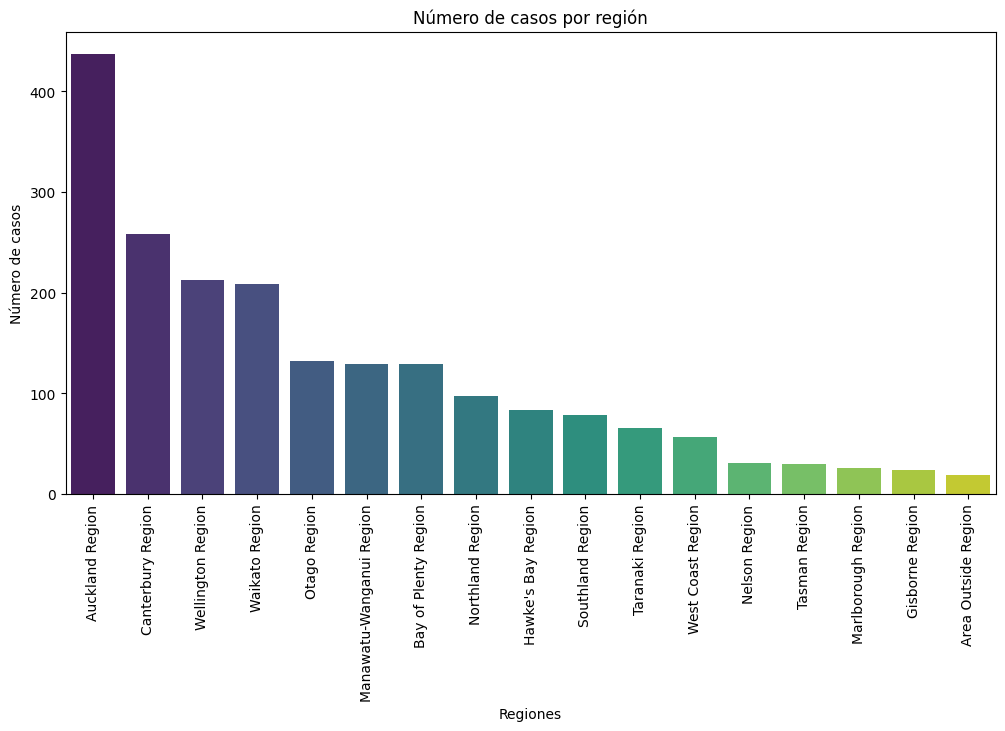

In [ ]:
import warnings
warnings.filterwarnings("ignore")

plt.figure(figsize=(12, 6))
sns.barplot(x='Region_2013_label', y='count', data = frecuencias_region, palette='viridis')
plt.title('Número de casos por región')
plt.xlabel('Regiones')
plt.ylabel('Número de casos')
plt.xticks(rotation=90)
plt.show()

Similar al caso anterior, se detaca que en esta variable hay una moda con las principales zonas urbanas y una menor frecuencia con las áreas urbanas secundarias. Esto quiere decir que las primeras mencionadas son las áreas más grandes, las que tienen una mayor cantidad de ciudades, no de casos.

Lo anterior puede explicarse porque es un país que es mayoritariamente urbano o porque estas dinámicas de violencia -que puede catalogarse como violencia basada en género- se presentan o denuncian mayoritariamente en sectores urbanos.

In [ ]:
frecuencias_area = data['Urban_area_type'].value_counts().reset_index()
print(frecuencias_area)

        Urban_area_type  count
0       Main urban area   1112
1            Rural area    640
2      Minor urban area    137
3  Secondary urban area    131


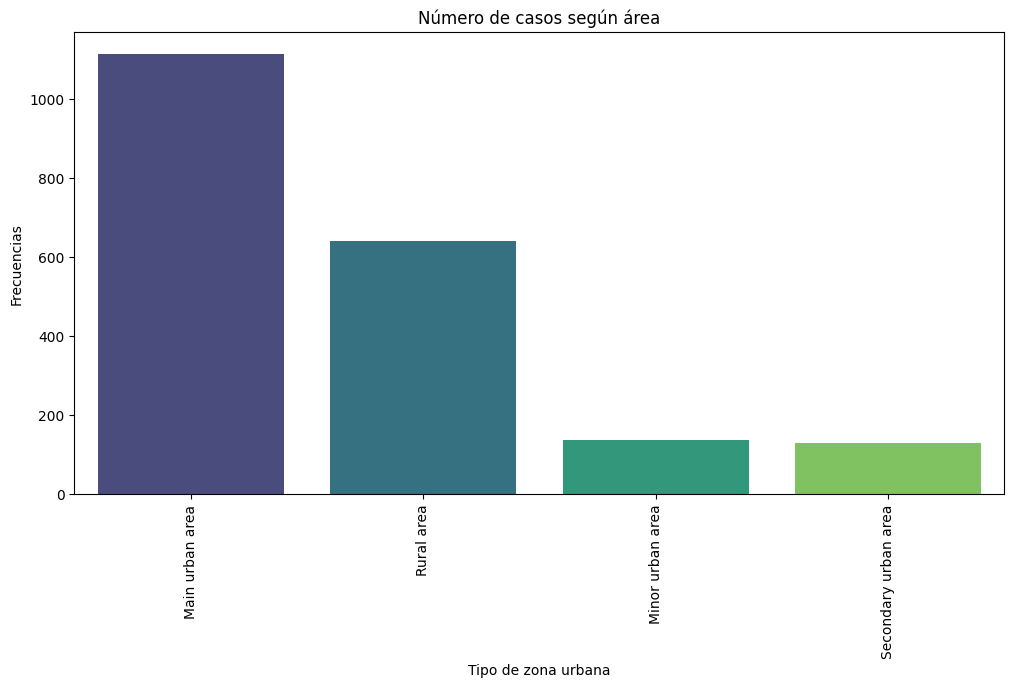

In [ ]:
import warnings
warnings.filterwarnings("ignore")

plt.figure(figsize=(12, 6))
sns.barplot(x='Urban_area_type', y='count', data = frecuencias_area, palette='viridis')
plt.title('Número de casos según área')
plt.xlabel('Tipo de zona urbana')
plt.ylabel('Frecuencias')
plt.xticks(rotation=90)
plt.show()

Similar al caso anterior, se detaca que en esta variable hay una moda con las principales zonas urbanas y una menor frecuencia con las áreas urbanas secundarias. Esto quiere decir que las primeras mencionadas son las áreas más grandes, las que tienen una mayor cantidad de ciudades, no de casos.

Lo anterior puede explicarse porque es un país que es mayoritariamente urbano o porque estas dinámicas de violencia -que puede catalogarse como violencia basada en género- se presentan o denuncian mayoritariamente en sectores urbanos.

## Análisis bivariado

En este análisis bivariado, dada la naturaleza del conjunto de datos seleccionado, se puede ver la totalidad de los casos presentados en las autoridades, regiones y áreas urbanas. Este 'cruce' de variables es posible, y seguramente se el único, porque los registros son de cada ciudad en donde se presentaron casos en el año estudiado.

Con estos cruces, de igual manera, se pueden conocer dinámicas, como las frecuencias por las variables mencionadas. En este punto no se conocen las modas, que se conoció en el punto anterior, sino que permite conocer dónde se presentaron más casos.

El primer caso encontrado es el de regiones, que son grupos de autoridades territoriales. En este caso, el gráfico demuestra que en la región de Auckland se presentan ocho mil casos, siendo el lugar donde más se presenta, seguido de Canterbury, con cerca de tres mil. Por otro lado, las variables con menos frecuencias es Marborough, Tasman y West Coast.

In [ ]:
total_regiones = data.groupby('Region_2013_label')['Victimisations_calendar_year_2015'].sum().reset_index()
total_regiones.columns = ['Región', 'Casos']
print(total_regiones)

                      Región  Casos
0        Area Outside Region      0
1            Auckland Region   8010
2       Bay of Plenty Region   1751
3          Canterbury Region   2942
4            Gisborne Region    436
5         Hawke's Bay Region   1068
6   Manawatu-Wanganui Region   1270
7         Marlborough Region    209
8              Nelson Region    357
9           Northland Region    905
10              Otago Region   1142
11          Southland Region    381
12           Taranaki Region    493
13             Tasman Region    161
14            Waikato Region   2330
15         Wellington Region   2459
16         West Coast Region    121


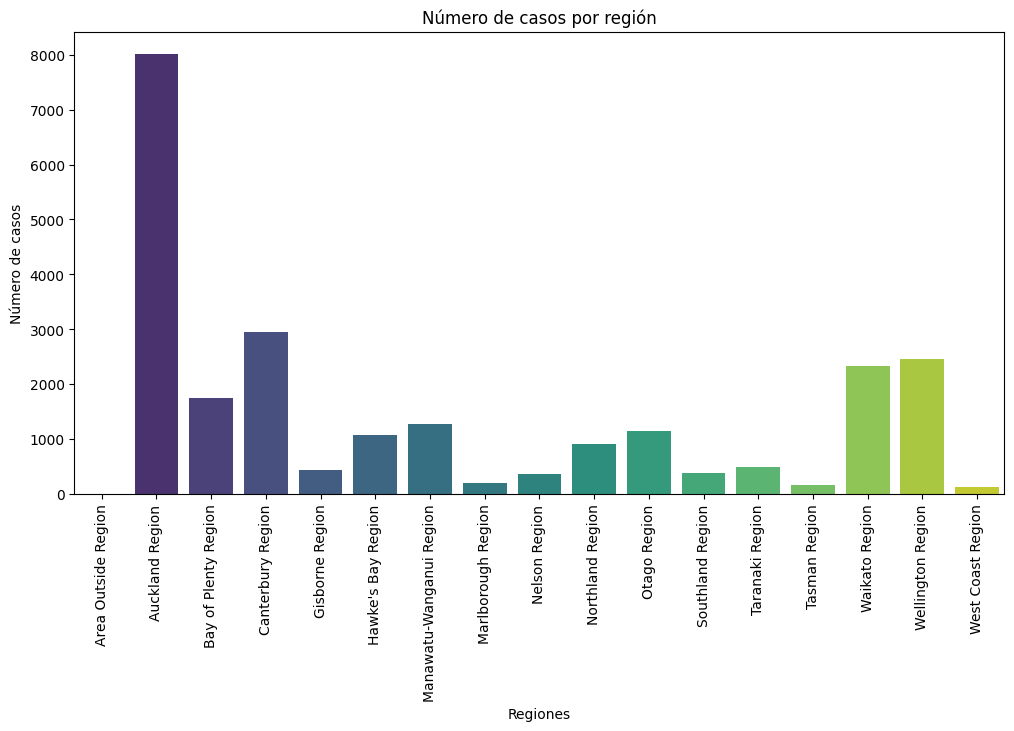

In [ ]:
import warnings
warnings.filterwarnings("ignore")

plt.figure(figsize=(12, 6))
sns.barplot(x='Región', y='Casos', data=total_regiones, palette='viridis')
plt.title('Número de casos por región')
plt.xlabel('Regiones')
plt.ylabel('Número de casos')
plt.xticks(rotation=90)
plt.show()

Según las autoridades territoriales, que son grupos de ciudades, se puede notar que Auckland es el lugar que más dato registra, con mayoría, caso ocho mil casos. En Christchurch tiene más de dos mil casos, una cuarta parte del valor más alto.

In [ ]:
total_autoridades = data.groupby('Territorial_authority_area_2013_label')['Victimisations_calendar_year_2015'].sum().reset_index()
total_autoridades.columns = ['Autoridad', 'Casos']
print(total_autoridades)

                             Autoridad  Casos
0   Area Outside Territorial Authority      0
1                   Ashburton District    121
2                             Auckland   8010
3                      Buller District     25
4                   Carterton District     22
..                                 ...    ...
63                     Wellington City   1022
64      Western Bay of Plenty District    137
65                   Westland District     26
66                  Whakatane District    206
67                  Whangarei District    447

[68 rows x 2 columns]


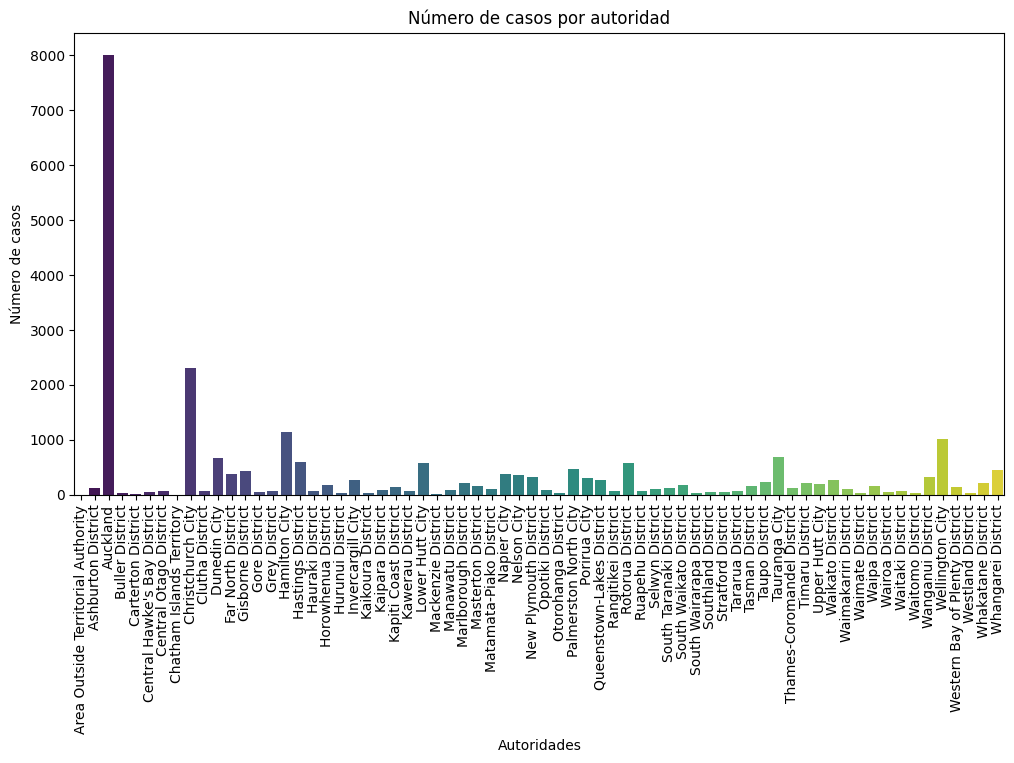

In [ ]:
import warnings
warnings.filterwarnings("ignore")

plt.figure(figsize=(12, 6))
sns.barplot(x='Autoridad', y='Casos', data=total_autoridades, palette='viridis')
plt.title('Número de casos por autoridad')
plt.xlabel('Autoridades')
plt.ylabel('Número de casos')
plt.xticks(rotation=90)
plt.show()

Las zonas urbanas son cuatro: principal, menor, rural y secundario. En este caso, como en los casos anteriores, en el sector principal, o urbano, son más de 17500 casos. Este caso congrega la mayoría de los casos registrados en el dataset. A estos le siguen el sector menor, secundario y rural. La distribución no es normal, puesto que está sesgado hacia la izquieda.

In [ ]:
total_areas_urbanas = data.groupby('Urban_area_type')['Victimisations_calendar_year_2015'].sum().reset_index()
total_areas_urbanas.columns = ['Zona urbana', 'Casos']
print(total_areas_urbanas)

            Zona urbana  Casos
0       Main urban area  18991
1      Minor urban area   1989
2            Rural area   1349
3  Secondary urban area   1706


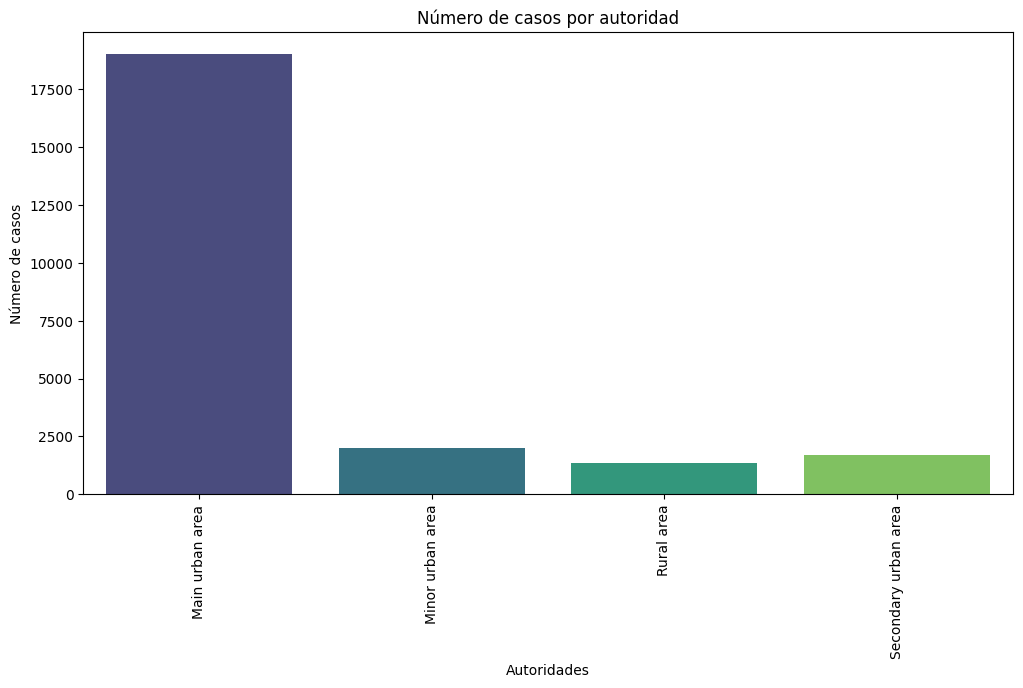

In [ ]:
import warnings
warnings.filterwarnings("ignore")

plt.figure(figsize=(12, 6))
sns.barplot(x='Zona urbana', y='Casos', data=total_areas_urbanas, palette='viridis')
plt.title('Número de casos por autoridad')
plt.xlabel('Autoridades')
plt.ylabel('Número de casos')
plt.xticks(rotation=90)
plt.show()

# conclusiones

Principales hallazgos del análisis:

1. **Diferencias regionales en la victimización**: Se observó que algunas regiones presentan una mayor concentración de casos de victimización en comparación con otras. Esto sugiere que ciertos factores geográficos o socioeconómicos pueden estar influyendo en la distribución de los delitos.

2. **Impacto del tipo de área urbana**: Las áreas urbanas principales tienen una mayor cantidad de casos de victimización en comparación con áreas suburbanas o rurales. Esto refuerza la idea de que la densidad poblacional y la actividad comercial pueden influir en la incidencia del crimen.

3. **Variabilidad entre autoridades territoriales**: Se identificó que ciertas autoridades territoriales registran tasas más altas de victimización. Esto podría deberse a diferencias en la aplicación de la ley, niveles de seguridad, condiciones socioeconómicas o incluso la forma en que se reportan los incidentes.
4. **Presencia de valores atípicos**: Se utilizaron diagramas de caja -boxplots- para identificar valores atípicos en los datos de victimización. Esto permitió detectar regiones o áreas con niveles inusualmente altos de delitos, lo que podría indicar la necesidad de estudios adicionales o estrategias de mitigación específicas.
5. **Frecuencia de casos por región**: Se encontró que ciertas regiones concentran un mayor número de incidentes de victimización. Este hallazgo sugiere que pueden ser necesarias intervenciones específicas en estas áreas para reducir los índices de criminalidad.
6. **Mayor incidencia en áreas urbanas**: El análisis mostró que las zonas urbanas tienen una mayor frecuencia de delitos en comparación con otras áreas. Esto respalda la hipótesis de que la densidad poblacional y la actividad económica pueden estar correlacionadas con una mayor tasa de criminalidad.
Estos hallazgos pueden ser utilizados para diseñar estrategias de seguridad más efectivas o para orientar futuras investigaciones sobre los factores que influyen en la victimización en diferentes áreas.